# **ACF and PACF of ARIMA(p,d,q) and SARIMA(p,d,q)(P,D,Q,S)model**

In [ ]:
#base library
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# statstical model library
import statsmodels.api as sm
import statsmodels.tsa.api as tsa

# some required library (just to make the example clearer)
#plot acf and pacf
def plotACF_PACFsample(dataset, num_lag, title):
  fig,ax = plt.subplots(1,2,figsize=(16,4), tight_layout=True)
  _ = sm.graphics.tsa.plot_acf(dataset, lags=num_lag, title='Sample ACF', ax=ax[0])
  _ = sm.graphics.tsa.plot_pacf(dataset, lags=num_lag, title='Sample PACF', ax=ax[1])
  fig.suptitle(title, fontsize=16)

# create a differenced series
def difference(dataset, interval):
	diff = list()
	for i in range(interval, len(dataset)):
		value = dataset[i] - dataset[i - interval]
		diff.append(value)
	return pd.Series(diff)


# **EXAMPLE**
Comparison of ARMA, ARIMA and SARIMA processess.

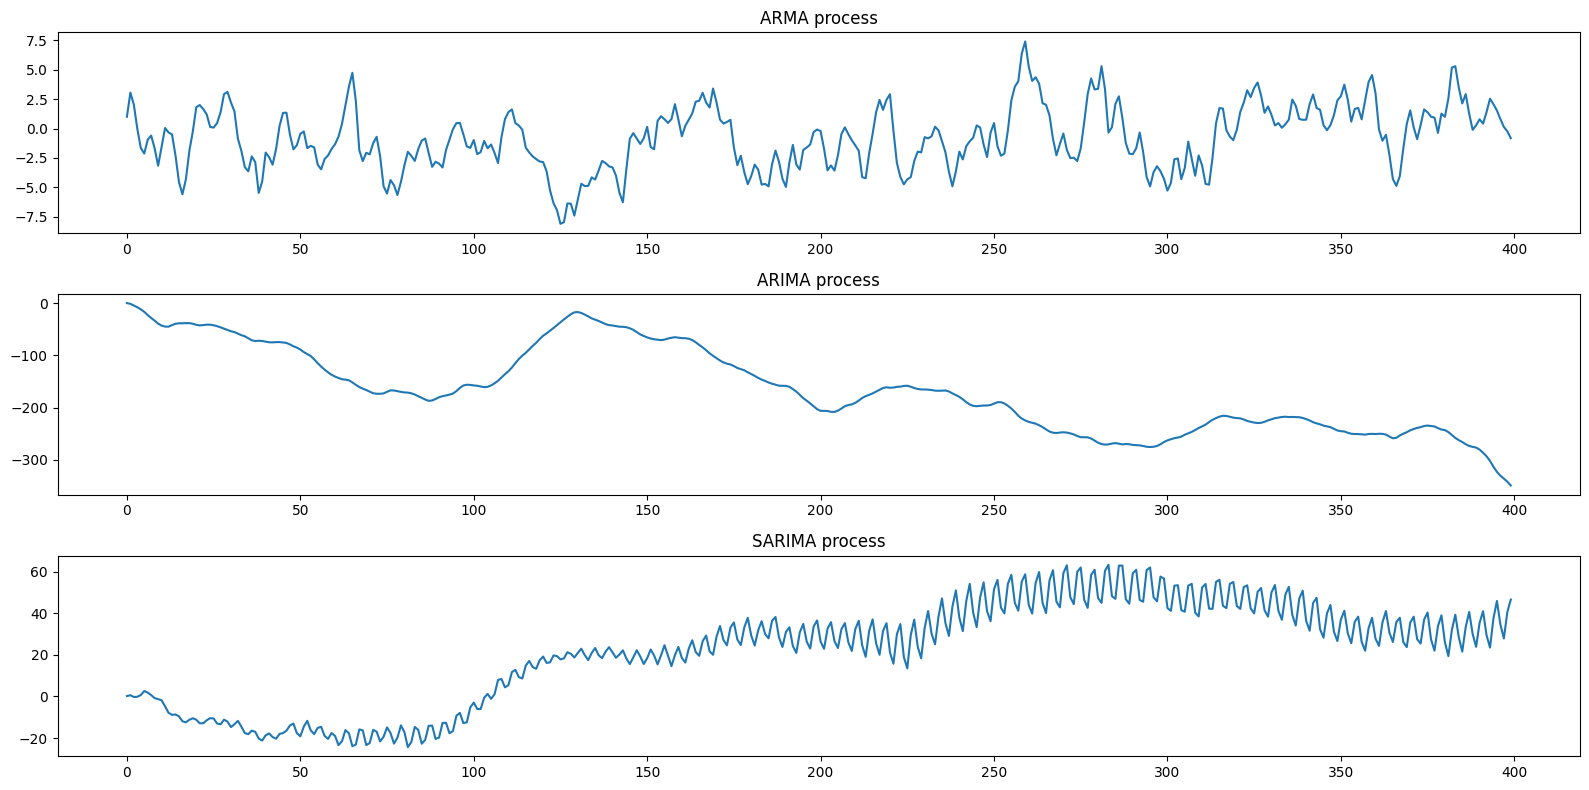

In [ ]:

num_sample = 400
arma_process = tsa.ArmaProcess([1,-0.8], [1,0.8])
arima_process = tsa.ArmaProcess([1, -1.8, 0.8], [1,0.8]) #arima(1,1,1)
sarima_process = tsa.ArmaProcess([1, -0.8, 0, 0, -1, 0.8], [1,0.8]) #sarima(1,0,1)x(0,1,0,4)
#generate sample
arma_data = arma_process.generate_sample(num_sample)
arima_data = arima_process.generate_sample(num_sample)
sarima_data = sarima_process.generate_sample(num_sample)

x = np.arange(0,num_sample, 1)
fig, ax = plt.subplots(3,1, figsize=(16,8), tight_layout=True)
ax[0].plot(x, arma_data); ax[0].title.set_text('ARMA process')
ax[1].plot(x, arima_data); ax[1].title.set_text('ARIMA process')
ax[2].plot(x, sarima_data); ax[2].title.set_text('SARIMA process')


**ACF and PACF of MA, AR and ARMA process**

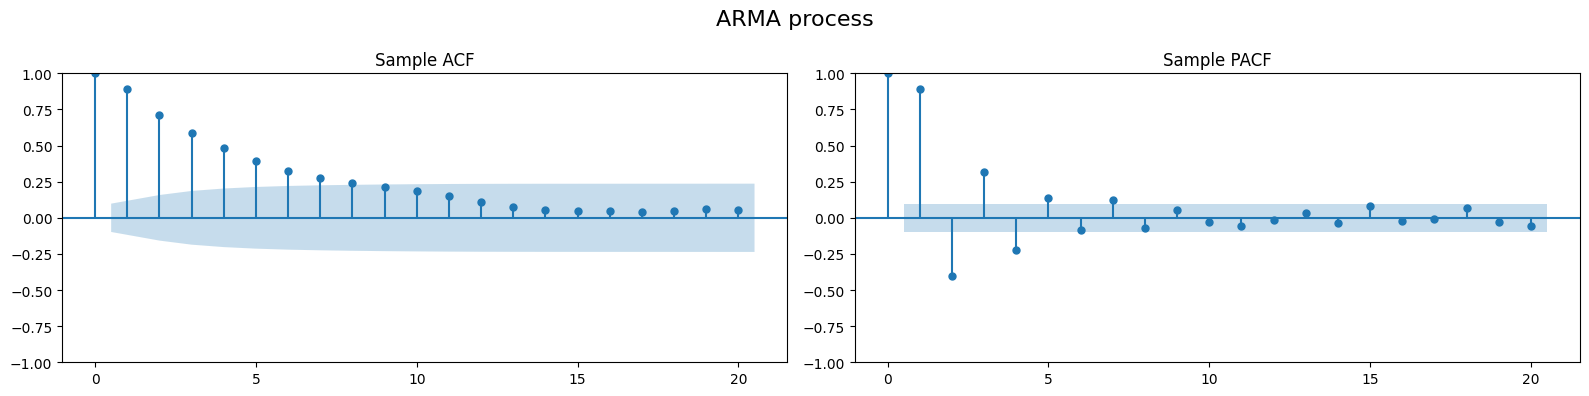

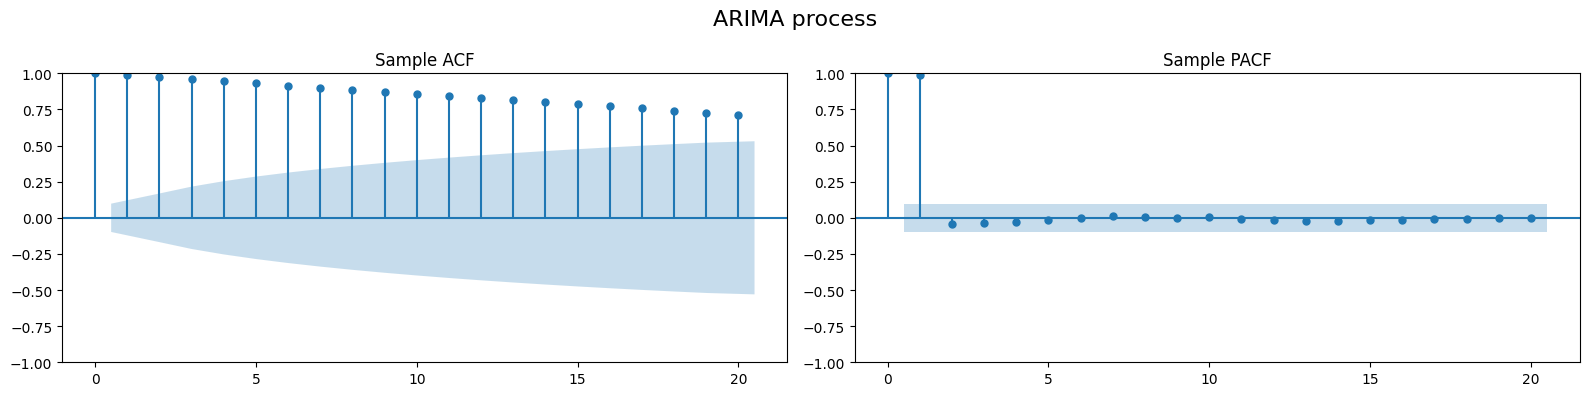

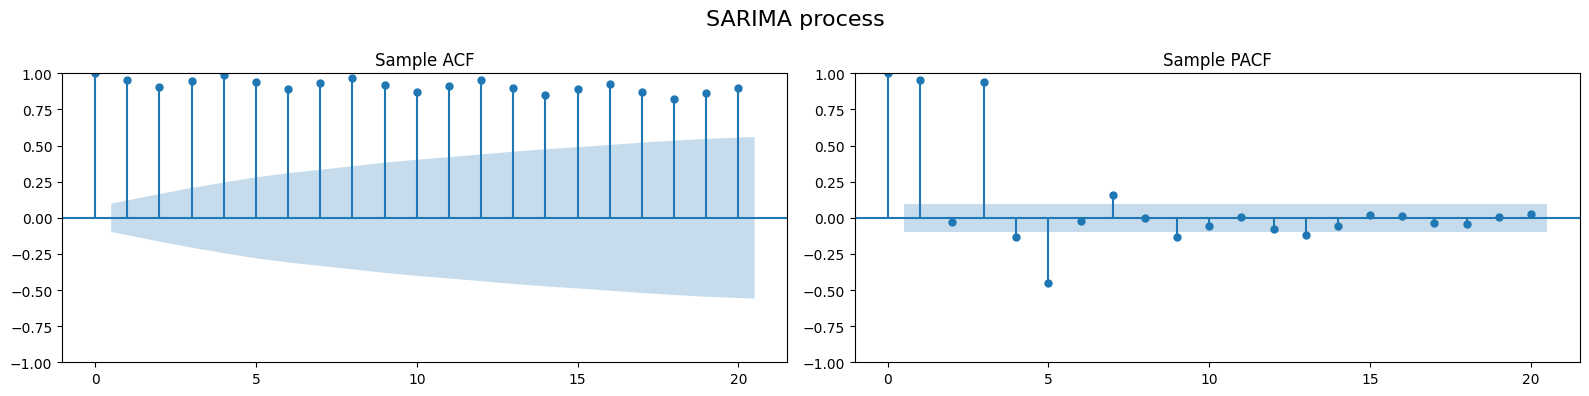

In [ ]:
num_lag = 20
plotACF_PACFsample(arma_data, num_lag, 'ARMA process')
plotACF_PACFsample(arima_data, num_lag, 'ARIMA process')
plotACF_PACFsample(sarima_data, num_lag, 'SARIMA process')

**ACF and PACF of differenced ARIMA processes**

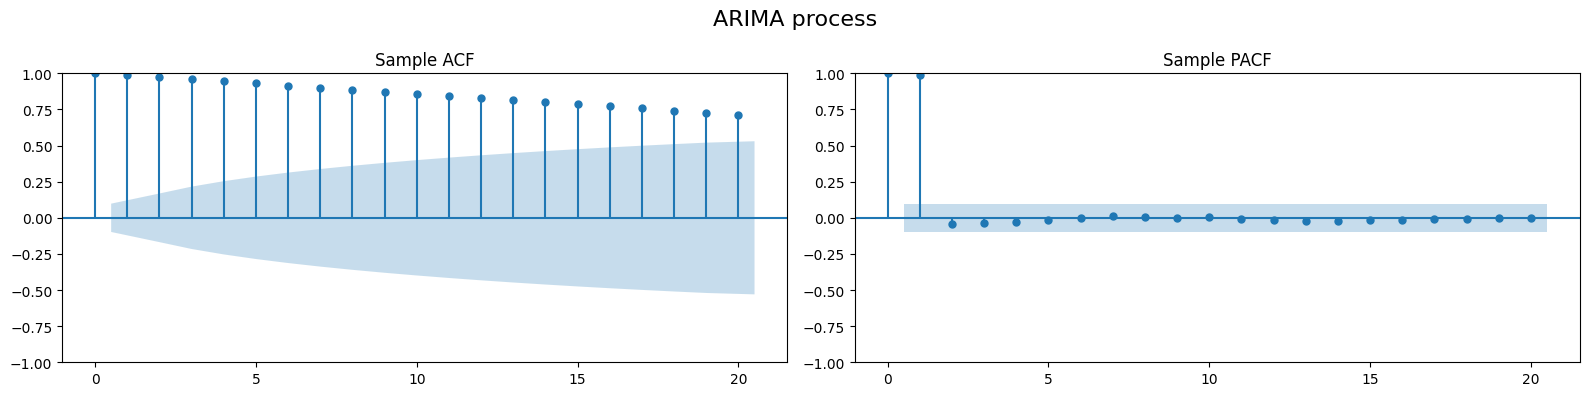

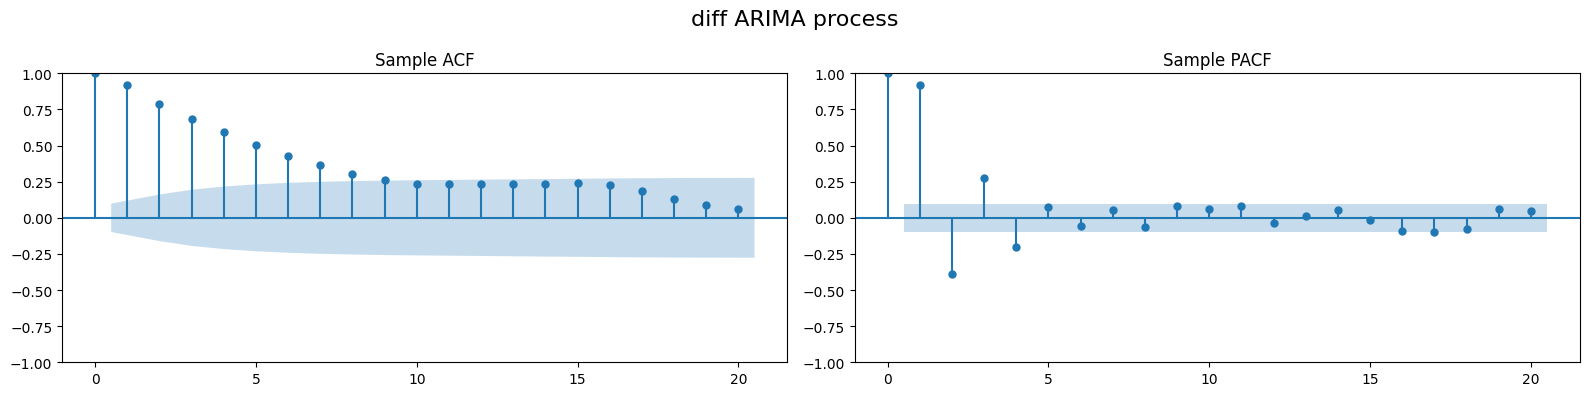

In [ ]:
num_lag = 20
arima_diff1data = difference(arima_data,1)

plotACF_PACFsample(arima_data, num_lag, 'ARIMA process')
plotACF_PACFsample(arima_diff1data, num_lag, 'diff ARIMA process')

**ACF and PACF of differenced SARIMA process**

In [ ]:
sarima_diff4data = difference(sarima_data,3)


plotACF_PACFsample(sarima_data, num_lag, 'SARIMA process')
plotACF_PACFsample(sarima_diff4data, num_lag, 'diff SARIMA process')